# EMA6938 — Data Science for Materials
## Week 5 Lab Notebook: ML Foundations, Tree-Based Models & Materials Descriptors

**Name:** *Ryan Tuggle*  
**Date:** *6/10/2026*  
**Kernel:** Python (matds)

---

**Chapters:** Sandfeld Ch. 11 + Lecture  
**Format:** Take-home. Due **Sunday 11:59 PM**.

**Dataset:** `data/week5_mp_featurized.csv` (instructor-provided, save in the same folder as this notebook)

---

### How to use this notebook
- **Demo cells** (`# LECTURE DEMO`) reproduce examples from the lecture. Run them, understand them.
- **Task cells** (`# YOUR CODE HERE`) require you to write code.
- **Reflection cells** require written markdown answers. Replace the italic placeholder text.
- Complete Parts A–C first (load, split, train). Parts D–F build on them.

---

**Submission:** Upload this `.ipynb` file to Canvas. Run `Kernel → Restart & Run All` before submitting to confirm all cells execute cleanly.

> **AI tool disclosure:** I used MS copilot to debug some lines of code where the syntax was giving me an error. 
---

**Final project reminder:** Topic proposal (1 paragraph) due this week! Submit via Canvas.

In [1]:
# Cell 0 — Environment check
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print(f'Python:      {sys.version.split()[0]}')
print(f'NumPy:       {np.__version__}')
print(f'pandas:      {pd.__version__}')
print(f'scikit-learn: already imported above')
print('\n\u2713 All imports successful.')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
})

Python:      3.11.15
NumPy:       2.4.6
pandas:      2.3.3
scikit-learn: already imported above

✓ All imports successful.


---
## Part A - Load & Prepare
**Connects to: Lecture Segment 2, Ch. 11**

### A1 - Load the featurized dataset
**Lecture demo - run and understand**

In [2]:
# Cell A1 - Load the featurized dataset
# LECTURE DEMO

df = pd.read_csv('data/week5_mp_featurized.csv')

print(f'Shape: {df.shape[0]:,} rows \u00d7 {df.shape[1]} columns')
print(f'\nFirst 5 columns: {list(df.columns[:5])}')
print(f'Last 5 columns:  {list(df.columns[-5:])}')
print(f'\nTarget column (band_gap):')
print(df['band_gap'].describe().round(3))

# Confirm MAGPIE features are present
magpie_cols = [c for c in df.columns if 'MagpieData' in c]
print(f'\nMAGPIE feature columns found: {len(magpie_cols)}')
print(f'Example: {magpie_cols[:3]}')

Shape: 9,389 rows × 137 columns

First 5 columns: ['mp_id', 'formula', 'band_gap', 'Ef_eV_atom', 'composition']
Last 5 columns:  ['MagpieData maximum SpaceGroupNumber', 'MagpieData range SpaceGroupNumber', 'MagpieData mean SpaceGroupNumber', 'MagpieData avg_dev SpaceGroupNumber', 'MagpieData mode SpaceGroupNumber']

Target column (band_gap):
count    9389.000
mean        1.772
std         1.657
min         0.000
25%         0.000
50%         1.565
75%         3.052
max         8.375
Name: band_gap, dtype: float64

MAGPIE feature columns found: 132
Example: ['MagpieData minimum Number', 'MagpieData maximum Number', 'MagpieData range Number']


### A2 - Drop missing values and report

In [3]:
# Cell A2 — Drop rows with missing band_gap or missing MAGPIE features
# LECTURE DEMO

n_before = len(df)

# Drop rows missing the target
df = df.dropna(subset=['band_gap'])

# Drop rows missing any MAGPIE feature
df = df.dropna(subset=magpie_cols)

n_after = len(df)
print(f'Rows before: {n_before:,}')
print(f'Rows after:  {n_after:,}')
print(f'Dropped:     {n_before - n_after:,} ({100*(n_before-n_after)/n_before:.1f}%)')
print(f'\nband_gap range: {df["band_gap"].min():.2f} \u2013 {df["band_gap"].max():.2f} eV')

Rows before: 9,389
Rows after:  9,389
Dropped:     0 (0.0%)

band_gap range: 0.00 – 8.38 eV


### A3 - Separate X and y
**Lecture demo**

In [4]:
# Cell A3 — Separate feature matrix X and target vector y
# LECTURE DEMO

X = df[magpie_cols].copy()
y = df['band_gap'].copy()

print(f'X shape: {X.shape}  (samples \u00d7 features)')
print(f'y shape: {y.shape}')
print(f'\ny (band_gap) summary:')
print(y.describe().round(3))

X shape: (9389, 132)  (samples × features)
y shape: (9389,)

y (band_gap) summary:
count    9389.000
mean        1.772
std         1.657
min         0.000
25%         0.000
50%         1.565
75%         3.052
max         8.375
Name: band_gap, dtype: float64


---
## Part B - Train/Test Split
**Connects to: Lecture Segment 3, Ch. 11**

### B1 - Stratified 80/20 split
**Lecture demo**

In [5]:
# Cell B1 — Stratified train/test split
# LECTURE DEMO

# Bin the target for stratification
y_bins = pd.qcut(y, q=5, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y_bins
)

print(f'Train: {len(X_train):,} samples')
print(f'Test:  {len(X_test):,} samples')
print(f'\nTrain y mean: {y_train.mean():.3f} eV  Test y mean: {y_test.mean():.3f} eV')
print(f'Train y std:  {y_train.std():.3f} eV  Test y std:  {y_test.std():.3f} eV')

Train: 7,511 samples
Test:  1,878 samples

Train y mean: 1.770 eV  Test y mean: 1.778 eV
Train y std:  1.658 eV  Test y std:  1.655 eV


### B2 - Confirm distributions match

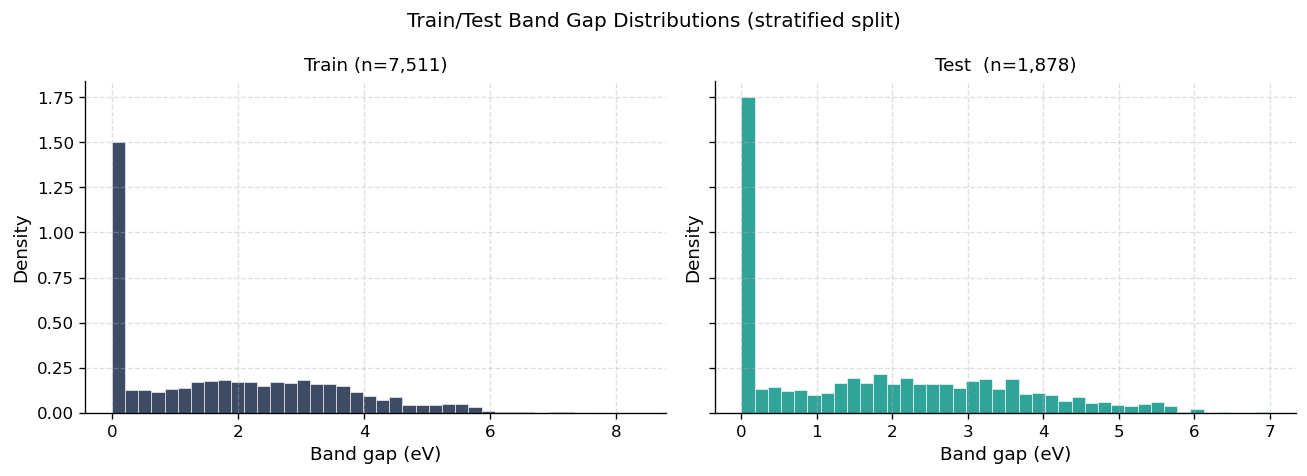

In [6]:
# Cell B2 — Plot y_train and y_test distributions side by side
# LECTURE DEMO

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, data, label, color in [
    (axes[0], y_train, f'Train (n={len(y_train):,})', '#1C2B4A'),
    (axes[1], y_test,  f'Test  (n={len(y_test):,})',  '#0D9488'),
]:
    ax.hist(data, bins=40, color=color, alpha=0.85,
            density=True, edgecolor='white', linewidth=0.4)
    ax.set_xlabel('Band gap (eV)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(label, fontsize=11)

plt.suptitle('Train/Test Band Gap Distributions (stratified split)', fontsize=12)
plt.tight_layout()
plt.savefig('B2_train_test_distributions.png', dpi=150)
plt.show()

---
## Part C - Train and Compare Three Models
**Connects to: Lecture Segment 4, Ch. 11**

### C1 — Decision tree baseline

In [7]:
# Cell C1 — Decision tree (max_depth=5)
# LECTURE DEMO

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

mae_dt  = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt   = r2_score(y_test, y_pred_dt)

print('Decision Tree (max_depth=5):')
print(f'  MAE:  {mae_dt:.3f} eV')
print(f'  RMSE: {rmse_dt:.3f} eV')
print(f'  R\u00b2:   {r2_dt:.3f}')

Decision Tree (max_depth=5):
  MAE:  0.946 eV
  RMSE: 1.192 eV
  R²:   0.481


### C2 - Random forest
**Lecture demo**

In [8]:
# Cell C2 — Random forest (n_estimators=100)
# LECTURE DEMO

rf = RandomForestRegressor(
    n_estimators=100,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print('Random Forest (n_estimators=100):')
print(f'  MAE:  {mae_rf:.3f} eV')
print(f'  RMSE: {rmse_rf:.3f} eV')
print(f'  R\u00b2:   {r2_rf:.3f}')

Random Forest (n_estimators=100):
  MAE:  0.562 eV
  RMSE: 0.777 eV
  R²:   0.779


### C3 - Gradient boosting

In [9]:
# Cell C3 - Gradient boosting
# LECTURE DEMO

gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

mae_gb  = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb   = r2_score(y_test, y_pred_gb)

print('Gradient Boosting (n_estimators=200, lr=0.05):')
print(f'  MAE:  {mae_gb:.3f} eV')
print(f'  RMSE: {rmse_gb:.3f} eV')
print(f'  R\u00b2:   {r2_gb:.3f}')

Gradient Boosting (n_estimators=200, lr=0.05):
  MAE:  0.703 eV
  RMSE: 0.888 eV
  R²:   0.712


### C4 - Comparison table and prediction scatter
**Task**

            Model  MAE (eV)  RMSE (eV)       R^2
0   Decision Tree  0.945558   1.192044  0.480867
1   Random Forest  0.561769   0.776965  0.779455
2  Gradient Boost  0.703364   0.888200  0.711786


Text(0.5, 1.0, 'y_predict_rf vs. y_test, r2=0.779')

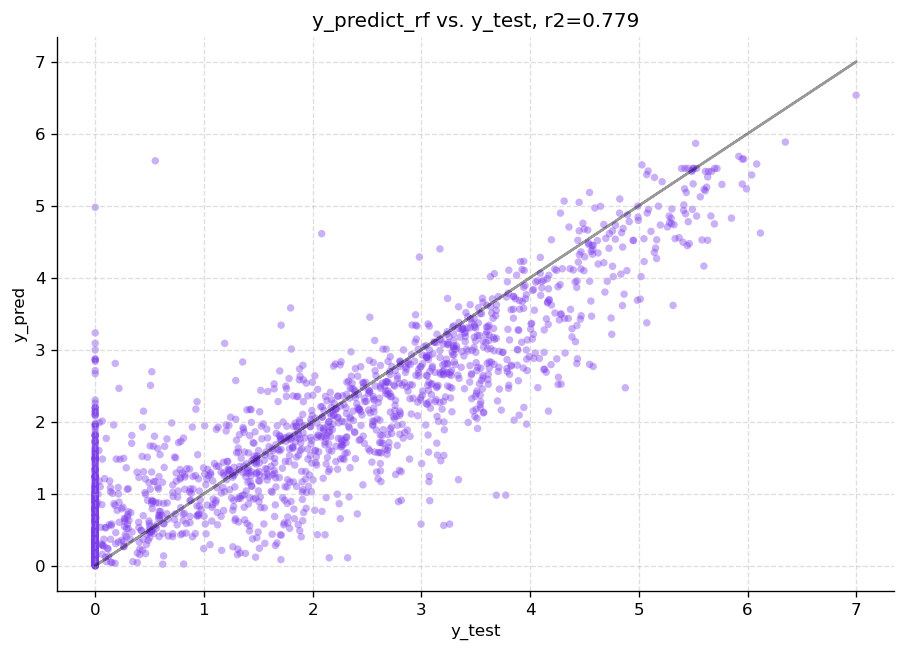

In [10]:
# Cell C4 — Model comparison table + prediction vs truth scatter
# YOUR CODE HERE

# 1. Print a formatted comparison table:
#    Model | MAE (eV) | RMSE (eV) | R²
#    Decision Tree | ... | ... | ...
#    Random Forest | ... | ... | ...
#    Gradient Boost| ... | ... | ...
df_dict={'Model':['Decision Tree','Random Forest','Gradient Boost'],'MAE (eV)':[mae_dt,mae_rf,mae_gb],'RMSE (eV)':[rmse_dt,rmse_rf,rmse_gb],'R^2':[r2_dt,r2_rf,r2_gb]}

compare_df=pd.DataFrame(df_dict)
print(compare_df.to_string())
# 2. For the best model, plot: y_test (x-axis) vs y_pred (y-axis)
#    Add a y=x diagonal line. Label axes. Add R² to the title.
fig,ax=plt.subplots(figsize=(9,6))

ax.scatter(y_test,y_pred_rf,alpha=0.4, s=20, color='#7C3AED', edgecolors='none')
ax.plot(y_test, y_test, color='black', alpha=0.4)
ax.set_xlabel('y_test')
ax.set_ylabel('y_pred')
ax.set_title(f"y_predict_rf vs. y_test, r2={r2_rf:0.3f}")


# YOUR CODE HERE



**C4 Reflection** *(answer in this cell)*

Which model performed best? By how much does it beat the decision tree? Does the prediction vs. truth scatter show any systematic pattern (e.g. over-prediction at high bandgap)?

*Your answer here:*
The random forest model performed best. It beats the decision tree by about 0.3 on the R2 value. I would say it is showing a consistent underprediction at mid to higher bandgaps. There seems to be a large overprediction at 0 eV where the metals are. 

---
## Part D - Interpret the Best Model
**Connects to: Lecture Segment 5, Ch. 11**

### D1 - Feature importance bar chart
**Lecture demo**

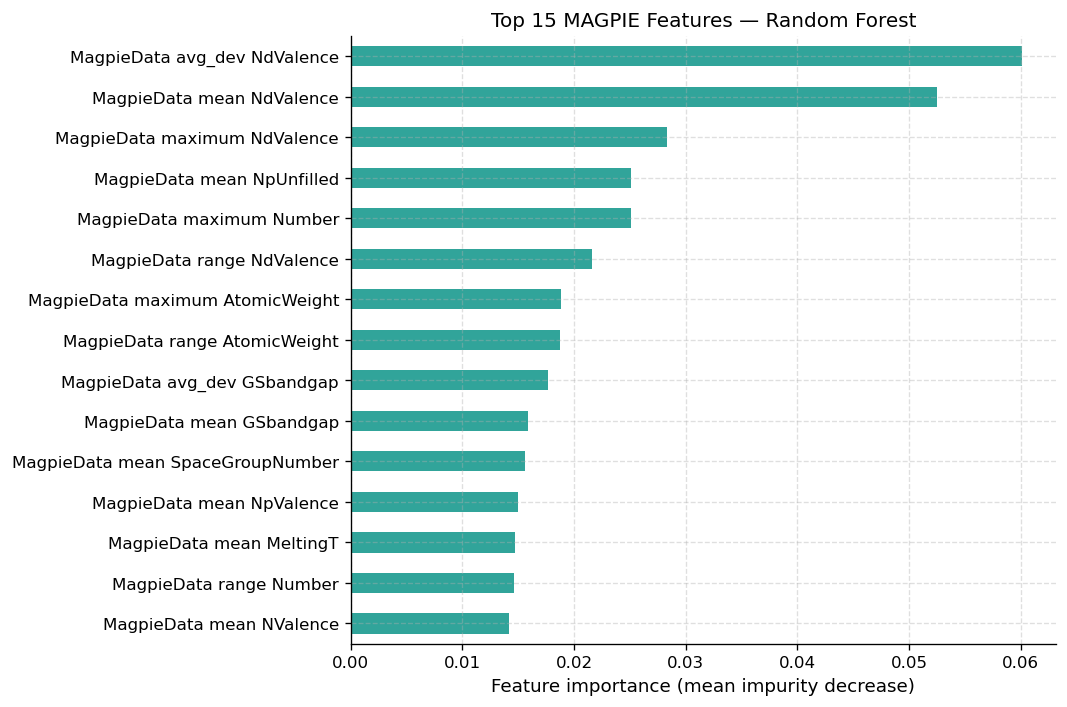

Top 10 features:
MagpieData avg_dev NdValence       0.0601
MagpieData mean NdValence          0.0525
MagpieData maximum NdValence       0.0283
MagpieData mean NpUnfilled         0.0251
MagpieData maximum Number          0.0251
MagpieData range NdValence         0.0216
MagpieData maximum AtomicWeight    0.0188
MagpieData range AtomicWeight      0.0188
MagpieData avg_dev GSbandgap       0.0176
MagpieData mean GSbandgap          0.0158


In [11]:
# Cell D1 — Feature importance: top 15 MAGPIE features
# LECTURE DEMO  (uses rf - switch to gb if GB performed better)

best_model = rf   # change to gb if gradient boosting was better

importances = pd.Series(
    best_model.feature_importances_,
    index=magpie_cols
).sort_values(ascending=False)

top15 = importances.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top15.plot(kind='barh', ax=ax, color='#0D9488', alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel('Feature importance (mean impurity decrease)', fontsize=11)
ax.set_title('Top 15 MAGPIE Features — Random Forest', fontsize=12)
plt.tight_layout()
plt.savefig('D1_feature_importance.png', dpi=150)
plt.show()

print('Top 10 features:')
print(top15.head(10).round(4).to_string())

### D2 - Residual plot

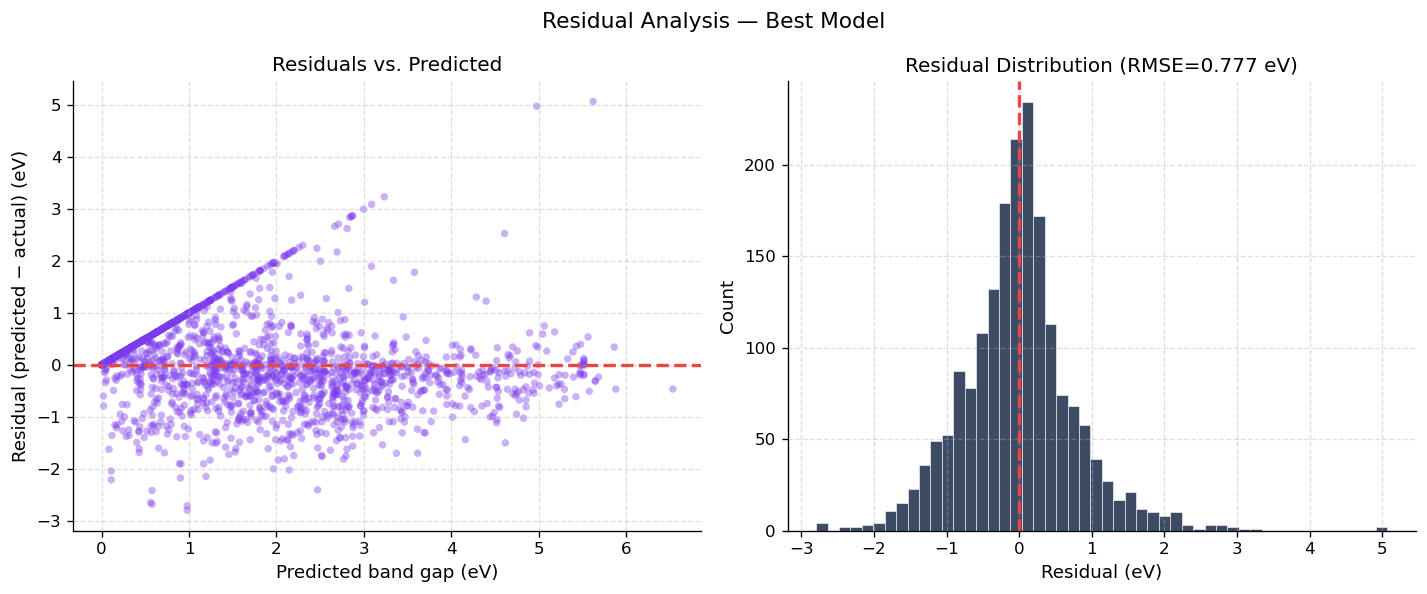

Mean residual: -0.0061 eV  (should be near 0)
Std residual:  0.7771 eV
Max |residual|: 5.071 eV

Largest error entry:
formula      Ca(BO2)3
band_gap       0.5526
mp_id       mp-729083
Name: 2034, dtype: object


In [12]:
# Cell D2 — Residual plot
# LECTURE DEMO

y_pred_best = best_model.predict(X_test)
residuals   = y_pred_best - y_test

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.4, s=20, color='#7C3AED', edgecolors='none')
axes[0].axhline(0, color='#EF4444', ls='--', lw=2)
axes[0].set_xlabel('Predicted band gap (eV)', fontsize=11)
axes[0].set_ylabel('Residual (predicted \u2212 actual) (eV)', fontsize=11)
axes[0].set_title('Residuals vs. Predicted', fontsize=12)

# Residual histogram
axes[1].hist(residuals, bins=50, color='#1C2B4A', alpha=0.85,
             edgecolor='white', linewidth=0.4)
axes[1].axvline(0, color='#EF4444', ls='--', lw=2)
axes[1].set_xlabel('Residual (eV)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title(f'Residual Distribution (RMSE={rmse_rf:.3f} eV)', fontsize=12)

plt.suptitle('Residual Analysis — Best Model', fontsize=13)
plt.tight_layout()
plt.savefig('D2_residuals.png', dpi=150)
plt.show()

print(f'Mean residual: {residuals.mean():.4f} eV  (should be near 0)')
print(f'Std residual:  {residuals.std():.4f} eV')
print(f'Max |residual|: {residuals.abs().max():.3f} eV')
print(f'\nLargest error entry:')
worst_idx = residuals.abs().idxmax()
print(df.loc[worst_idx, ['formula','band_gap','mp_id']])

### D3 - Task: physical interpretation of top feature

Top feature: MagpieData avg_dev NdValence
      MagpieData avg_dev NdValence  band_gap
2609                           0.0    4.4435
8438                           0.0    4.1609
9380                           0.0    0.0000

Pearson r: -0.34627510326585026


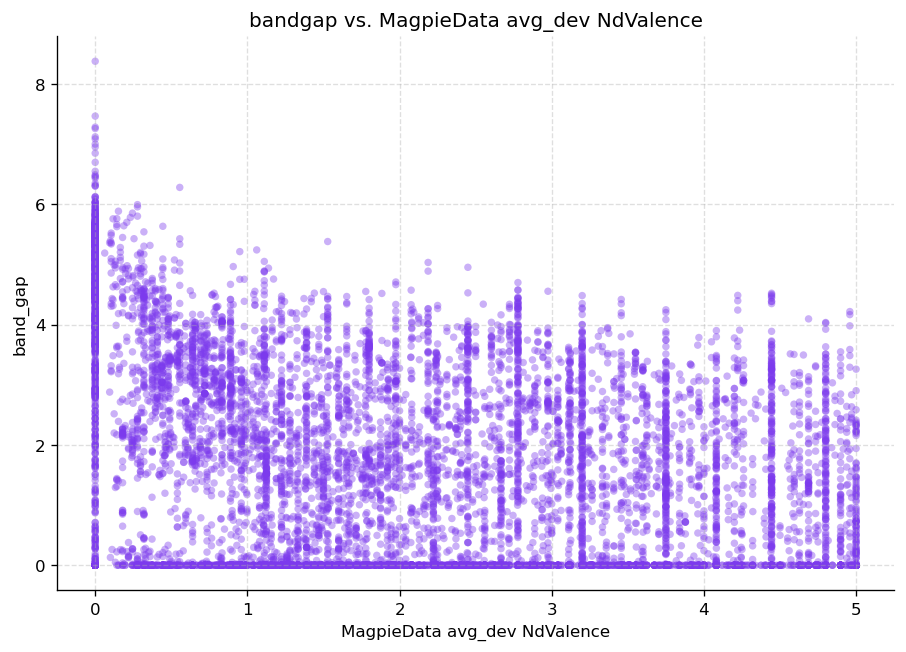

In [13]:
# Cell D3 — Task: scatter plot of top feature vs. band_gap
# YOUR CODE HERE

# 1. Identify the top-1 feature from D1
top_feature = importances.index[0]
print(f'Top feature: {top_feature}')

# 2. Make a scatter plot: top_feature (x) vs. band_gap (y)
#    Use df (not X_train/X_test) for this exploratory plot
df_plot = df[[top_feature, 'band_gap']]
df_plot = df_plot.sort_values(top_feature, ascending=True)
print(df_plot.head(3))
fig,ax=plt.subplots(figsize=(9,6))

ax.scatter(df_plot[top_feature],df_plot['band_gap'],alpha=0.4, s=20, color='#7C3AED', edgecolors='none')
ax.set_xlabel(top_feature)
ax.set_ylabel('band_gap')
ax.set_title(f'bandgap vs. {top_feature}')
# 3. Compute Pearson r between top_feature and band_gap

corr_p = df_plot[top_feature].corr(df_plot['band_gap'])
print("\nPearson r:", corr_p)

# YOUR CODE HERE



**D3 Reflection** *(answer in this cell)*

State the top feature name and provide a physical explanation: why would this compositional property predict bandgap in oxide materials? Does the scatter plot show a linear or nonlinear trend? Does this explain why RF outperforms Ridge?

*Your answer here:*
The top feature, avg_dev NdValence, predicts bandgap because cations with more empty d orbitals place their d states at higher energy, and these empty d states form the conduction band minimum in most oxides. When the d states sit higher, the separation between the O‑2p valence band and the metal‑d conduction band increases, producing a larger bandgap. The scatter plot shows a non-linear trend. This would explain why RF outperforms Ridge regression. 

---
## Part E - Linear Baseline (Ridge Regression)
**Connects to: Lecture Segment 5, Ch. 11**

### E1 - Standardise features
**Lecture demo**

In [14]:
# Cell E1 — StandardScaler: fit on train, transform train and test
# LECTURE DEMO

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print(f'X_train_scaled: mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}')
print('(mean ~0, std ~1 confirms scaling is correct)')
print(f'\nX_test_scaled:  mean={X_test_scaled.mean():.4f}, std={X_test_scaled.std():.4f}')
print('(slightly off from 0/1 — expected, scaler was fit on train data only)')

X_train_scaled: mean=0.0000, std=0.9692
(mean ~0, std ~1 confirms scaling is correct)

X_test_scaled:  mean=0.0047, std=0.9608
(slightly off from 0/1 — expected, scaler was fit on train data only)


### E2 - Train Ridge and compare
**Lecture demo**

In [15]:
# Cell E2 — Ridge regression and comparison
# LECTURE DEMO

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge   = r2_score(y_test, y_pred_ridge)

print("=" * 50)
print(f"{'Model':<20} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print("=" * 50)
print(f"{'Decision Tree':<20} {mae_dt:>8.3f} {rmse_dt:>8.3f} {r2_dt:>8.3f}")
print(f"{'Random Forest':<20} {mae_rf:>8.3f} {rmse_rf:>8.3f} {r2_rf:>8.3f}")
print(f"{'Gradient Boost':<20} {mae_gb:>8.3f} {rmse_gb:>8.3f} {r2_gb:>8.3f}")
print(f"{'Ridge (baseline)':<20} {mae_ridge:>8.3f} {rmse_ridge:>8.3f} {r2_ridge:>8.3f}")
print('='*50)

Model                     MAE     RMSE       R2
Decision Tree           0.946    1.192    0.481
Random Forest           0.562    0.777    0.779
Gradient Boost          0.703    0.888    0.712
Ridge (baseline)        1.024    1.236    0.442


### E2b — Cross-validation: a more reliable performance estimate
**Lecture demo — reproduce and understand**

In [16]:
# Cell E2b — 5-fold cross-validation on the Random Forest
# LECTURE DEMO

from sklearn.model_selection import cross_val_score
import numpy as np

# cross_val_score splits X and y into 5 folds automatically.
# For each fold: train on 4 folds, evaluate on the held-out fold.
# Returns one R² score per fold.
# Using the full (X, y) here because we are NOT tuning hyperparameters —
# no test-set information leaks into training.

rf_for_cv = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
cv_scores  = cross_val_score(rf_for_cv, X, y, cv=5, scoring='r2')

print(f"5-fold CV R² scores: {np.round(cv_scores, 3)}")
print(f"Mean CV R²:          {cv_scores.mean():.3f}")
print(f"Std  CV R²:          {cv_scores.std():.3f}")
print()
print(f"Test R² (from C2):   {r2_rf:.3f}")
print(f"Gap (test − CV):     {r2_rf - cv_scores.mean():.3f}")
print()
print("A large gap suggests the single 80/20 split was lucky or has leakage.")
print("Week 9 will use GroupKFold to address composition similarity leakage.")

5-fold CV R² scores: [0.727 0.764 0.771 0.771 0.771]
Mean CV R²:          0.761
Std  CV R²:          0.017

Test R² (from C2):   0.779
Gap (test − CV):     0.019

A large gap suggests the single 80/20 split was lucky or has leakage.
Week 9 will use GroupKFold to address composition similarity leakage.


### E3 - Task: cross-validation on the best model

In [17]:
# Cell E3 — Task: 5-fold cross-validation on the best model
# YOUR CODE HERE

# 1. Run 5-fold cross-validation on the Random Forest using cross_val_score
#    Use scoring='r2' and the full (X, y) — not the train/test split
#    (CV on the full dataset is valid here because we are not tuning hyperparameters)
rf_for_cv = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
cv_scores  = cross_val_score(rf_for_cv, X, y, cv=5, scoring='r2')
# 2. Print: mean CV R², standard deviation, and all 5 fold scores
print(f"Mean CV R²:          {cv_scores.mean():.3f}")
print(f"Std  CV R²:          {cv_scores.std():.3f}")
print(f"5-fold CV R² scores: {np.round(cv_scores, 3)}")
# 3. Compare mean CV R² to the test R² from C2.
#    Is the gap large? If so, what does that suggest about composition leakage?
print(f"mean CV R2 is {cv_scores.mean():.3f} and R2 from C2 is {r2_rf:.3f} and the gap is{(cv_scores.mean()-r2_rf):.3f}")

Mean CV R²:          0.761
Std  CV R²:          0.017
5-fold CV R² scores: [0.727 0.764 0.771 0.771 0.771]
mean CV R2 is 0.761 and R2 from C2 is 0.779 and the gap is-0.019


**E3 Reflection** *(answer in this cell)*

Is the mean CV R² close to the test R² you computed in C2?
If there is a large gap, what does this suggest about the relationship between
cross-validation strategy and data leakage in materials datasets?
(Hint: think about what Week 9 introduces.)

*Your answer here:*
Yes the R2 values are close. This indicates that the five fold CV is not being inflated by different structures of the same compostion in both the training and testing splits for each fold. 

---
## Part F - Reflection

### F1 - Feature importance and oxide chemistry

In 3–4 sentences: what does the feature importance plot tell you about which chemical properties control bandgap in oxide materials? Connect to a physical mechanism and do not just restate which feature ranked highest.

*Your answer here:*

The feature importance plot is telling me that in oxide materials the bandgap is primarily controlled by the number of unfilled d orbitals in the valence shell because these unfilled d states form the conduction band and sit at a higher energy than other unfilled orbitals. Likewise unfilled p orbitals is a top feature becuase these orbitals also sit at higher energy levels so when a cation has more of them it raises the bandgap. The plot also indicates that melting point predicts  bandgap in oxide materials. This is because a higher melting temperature indicates stronger bonding which means the valence states sit at a lower energy relative to the conduction band in these cases. 

### F2 - Final project connection

State the target property and material class you are considering for your final project. Would a composition-only random forest be sufficient for your problem, or do you expect to need structural features? What is the biggest challenge you anticipate in building your training dataset?

*Your answer here:*

The target property I am considering for my final project is the energy capacity of lithium ion batteries. I expect I will need structural features because the battery cathode materials are similar in composition, but strucutral variations could cause the cells to have different energy capacities. I anticipate the biggest challenge I will have is finding enough data that I trust to be accurate and will be a meaningful feature for the model. 

---
## Day 2

> **This section is covered during the Day 2 lab session.**

### Demo 1 - Hyperparameter sensitivity: how much does n_estimators matter?
**Instructor-led demo**

n_estimators=  10  R²=0.752  MAE=0.575 eV
n_estimators=  25  R²=0.768  MAE=0.560 eV
n_estimators=  50  R²=0.773  MAE=0.559 eV
n_estimators= 100  R²=0.779  MAE=0.554 eV
n_estimators= 200  R²=0.779  MAE=0.555 eV
n_estimators= 300  R²=0.780  MAE=0.553 eV
n_estimators= 500  R²=0.782  MAE=0.552 eV


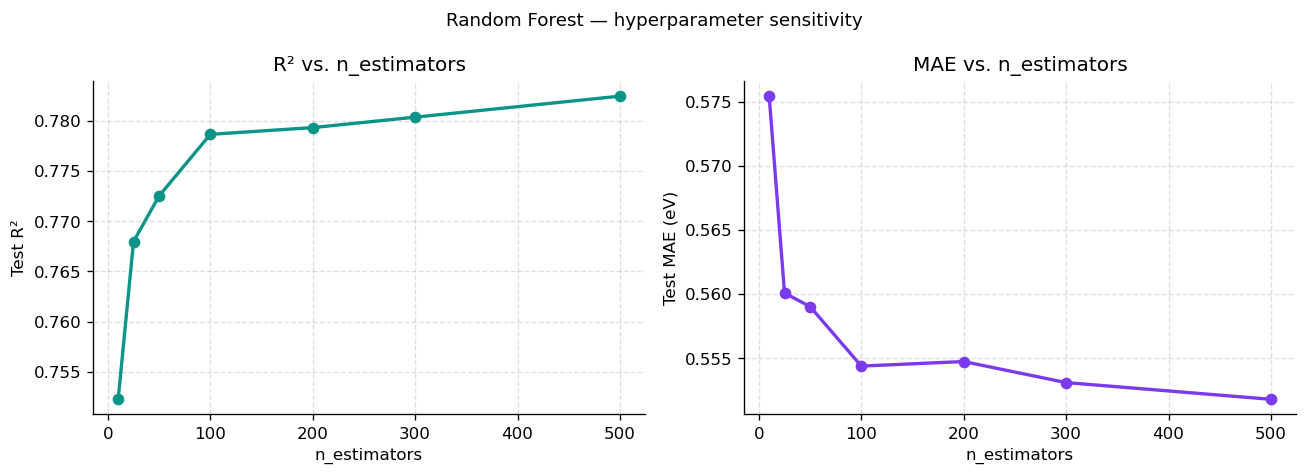

In [18]:
# Demo 1 — RF performance vs. n_estimators
# LECTURE DEMO

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

n_estimators_range = [10, 25, 50, 100, 200, 300, 500]
r2_scores, mae_scores = [], []

for n in n_estimators_range:
    rf_n = RandomForestRegressor(n_estimators=n, n_jobs=-1, random_state=42)
    rf_n.fit(X_train, y_train)
    y_pred_n = rf_n.predict(X_test)
    r2_scores.append(r2_score(y_test, y_pred_n))
    mae_scores.append(mean_absolute_error(y_test, y_pred_n))
    print(f"n_estimators={n:4d}  R²={r2_scores[-1]:.3f}  MAE={mae_scores[-1]:.3f} eV")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(n_estimators_range, r2_scores, 'o-', color='#0D9488', lw=2)
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('Test R²')
axes[0].set_title('R² vs. n_estimators')
axes[1].plot(n_estimators_range, mae_scores, 'o-', color='#7C3AED', lw=2)
axes[1].set_xlabel('n_estimators'); axes[1].set_ylabel('Test MAE (eV)')
axes[1].set_title('MAE vs. n_estimators')
plt.suptitle('Random Forest — hyperparameter sensitivity', fontsize=11)
plt.tight_layout()
plt.savefig('Day2_n_estimators.png', dpi=150, bbox_inches='tight')
plt.show()

### Demo 2 - Learning curve: are we data-limited?
**Instructor-led demo**

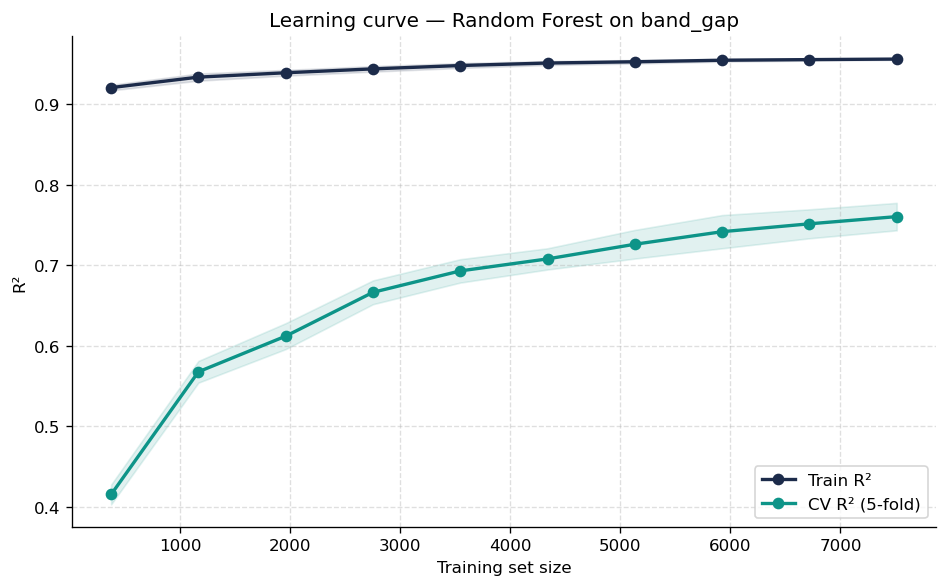

Train-CV gap at full training size: 0.196
Is CV R² still rising at the rightmost point? True


In [19]:
# Demo 2 — Learning curve for the RF model
# LECTURE DEMO

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42),
    X, y,
    train_sizes=np.linspace(0.05, 1.0, 10),
    cv=5, scoring='r2', n_jobs=-1
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_scores.mean(1), 'o-', color='#1C2B4A',
        lw=2, label='Train R²')
ax.fill_between(train_sizes,
                train_scores.mean(1) - train_scores.std(1),
                train_scores.mean(1) + train_scores.std(1),
                alpha=0.12, color='#1C2B4A')
ax.plot(train_sizes, val_scores.mean(1), 'o-', color='#0D9488',
        lw=2, label='CV R² (5-fold)')
ax.fill_between(train_sizes,
                val_scores.mean(1) - val_scores.std(1),
                val_scores.mean(1) + val_scores.std(1),
                alpha=0.12, color='#0D9488')
ax.set_xlabel('Training set size'); ax.set_ylabel('R²')
ax.set_title('Learning curve — Random Forest on band_gap')
ax.legend()
plt.tight_layout()
plt.savefig('Day2_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

gap = train_scores.mean(1)[-1] - val_scores.mean(1)[-1]
print(f"Train-CV gap at full training size: {gap:.3f}")
print("Is CV R² still rising at the rightmost point?",
      val_scores.mean(1)[-1] > val_scores.mean(1)[-2])

### Demo 3 - Where does the RF fail? Large-error material analysis
**Instructor-led demo**

In [20]:
#Demo 3 — Identify and investigate large-error materials
# LECTURE DEMO

# Use the RF trained in Part C (rf) and its predictions (y_pred_rf)
residuals  = np.abs(y_pred_rf - y_test.values)
formulas   = df['formula'].values if 'formula' in df.columns else ['?']*len(y_test)
crystal_sys = df['crystal_system'].values if 'crystal_system' in df.columns else ['?']*len(y_test)

# Get test-set indices (from the stratified split in B1)
# Reconstruct: y_test indices correspond to the test portion of the original df
idx_sorted = np.argsort(residuals)[::-1]

print("Top 10 largest prediction errors:")
print(f"{'Formula':20s}  {'Crystal sys':15s}  {'Actual':>8}  {'Pred':>8}  {'|Error|':>8}")
print("-"*67)
for pos in idx_sorted[:10]:
    original_idx = y_test.index[pos]
    f = df.loc[original_idx, 'formula'] if 'formula' in df.columns else '?'
    cs = df.loc[original_idx, 'crystal_system'] if 'crystal_system' in df.columns else '?'
    print(
        f"{f:20s}  {cs:15s}  "
        f"{y_test.iloc[pos]:8.3f}  "
        f"{y_pred_rf[pos]:8.3f}  "
        f"{residuals[pos]:8.3f} eV"
    )

print("\nDiscussion: what do the large-error materials have in common?")
print("  → Many are polymorphs (same formula, different structure)")
print("  → Composition-only features cannot distinguish TiO2 rutile from anatase")
print("  → This is the structural information gap Week 11 GNNs address")

Top 10 largest prediction errors:
Formula               Crystal sys        Actual      Pred   |Error|
-------------------------------------------------------------------
Ca(BO2)3              ?                   0.553     5.623     5.071 eV
NaSO4                 ?                   0.000     4.978     4.978 eV
Ba2ZrInO6             ?                   0.000     3.234     3.234 eV
Na5WO5                ?                   0.000     3.089     3.089 eV
Ba2YbTaO6             ?                   0.000     2.997     2.997 eV
Ta3Al4O14             ?                   0.000     2.874     2.874 eV
PuB4ClO8              ?                   0.000     2.865     2.865 eV
Eu(ClO4)3             ?                   0.000     2.857     2.857 eV
Ba2PrSnO6             ?                   0.000     2.839     2.839 eV
BiPO4                 ?                   3.776     0.980     2.796 eV

Discussion: what do the large-error materials have in common?
  → Many are polymorphs (same formula, different structur

**Day 2 Discussion questions:**

1. From Demo 1: at what n_estimators does performance plateau? What does this tell you about diminishing returns in ensemble size?

2. From Demo 2: is the CV R² still rising at the largest training size? If yes, would more data help more than better features? If no, what should you try next?

3. From Demo 3: do the large-error materials share a common structural feature that MAGPIE cannot encode? Connect to Week 11 (GNNs, what would a crystal-graph-based model do differently?

*Your answer here:*

1. Performance platueas at n=100 trees. This tells me that there is a marginal gain for over 100 estimators that doesn't justify the extra computation time.

2. The CV R2 is rising at the largest training size, albeit not by much. The increase is is so small though that adding another feature with high importance would more likely improve the R2. We might also adjust other hyperparameters to see if we get improvement.

3. They seem to be lacking the crystal structure. 

---
**Submission checklist:**
- [ ] All cells executed without errors
- [ ] C4: comparison table complete and scatter plot saved
- [ ] D1: feature importance bar chart saved
- [ ] D2: residual plots saved
- [ ] D3, E3: task cells contain working code
- [ ] All reflection cells answered (no placeholder text)
- [ ] AI disclosure note updated or deleted at the top of the notebook
- [ ] File renamed: `[LastName]_week5.ipynb`
**Final check:** Run `Kernel → Restart & Run All`. All cells must execute without errors before submitting.